# Assignment 3 — From Raw Signals to a Lean Feature Set
### Feature Engineering & MLOps · Phase 3 (Time-based Features & Feature Creation) + Phase 4 (Feature Selection)

**Dataset:** `daily_batch_performance.csv` — 730 days of PrepEdge institute performance data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.width', 120)
np.random.seed(42)

df = pd.read_csv('daily_batch_performance.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(df.shape)
df.head()


(730, 10)


## 4.1 — Phase 3: Time-based Features & Feature Creation

### 1. Load, sort, and plot `new_enrollments` over time

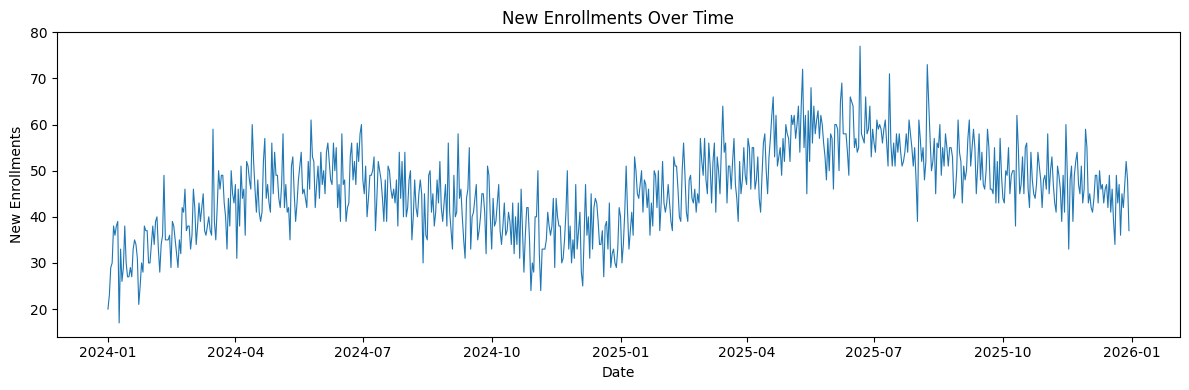

In [2]:
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['new_enrollments'], linewidth=0.8)
plt.title('New Enrollments Over Time')
plt.xlabel('Date')
plt.ylabel('New Enrollments')
plt.tight_layout()
plt.show()


**Observation:** `new_enrollments` shows a gentle upward trend over the two years, with clear repeating
weekly ripples on top of it (a weekly rhythm), consistent with enrollments being higher on some days of the
week than others.

### 2. Lag features

In [3]:
df['marketing_spend_lag1'] = df['marketing_spend'].shift(1)
df['marketing_spend_lag2'] = df['marketing_spend'].shift(2)

corr_same = df['marketing_spend'].corr(df['new_enrollments'])
corr_lag1 = df['marketing_spend_lag1'].corr(df['new_enrollments'])
corr_lag2 = df['marketing_spend_lag2'].corr(df['new_enrollments'])

print(f"Correlation with new_enrollments:")
print(f"  marketing_spend (same-day) : {corr_same:.4f}")
print(f"  marketing_spend_lag1       : {corr_lag1:.4f}")
print(f"  marketing_spend_lag2       : {corr_lag2:.4f}")


Correlation with new_enrollments:
  marketing_spend (same-day) : 0.1189
  marketing_spend_lag1       : -0.0092
  marketing_spend_lag2       : 0.2184


**Result:** `marketing_spend_lag2` (0.218) is the strongest of the three, clearly beating the same-day
value (0.119) and lag1 (-0.009). This makes real-world sense for a coaching institute: a prospective student
who sees an ad today doesn't walk in and enroll the same day — they think it over, maybe discuss with
parents, and typically show up a couple of days later. So the spend from two days ago is a better predictor
of today's enrollments than today's own spend.

### 3. Rolling features

In [4]:
df['enroll_roll_mean7'] = df['new_enrollments'].rolling(7).mean()
df['enroll_roll_std7'] = df['new_enrollments'].rolling(7).std()
df[['date', 'new_enrollments', 'enroll_roll_mean7', 'enroll_roll_std7']].iloc[5:12]


### 4. Cyclical encoding of day-of-week

In [5]:
df['day_of_week'] = df['date'].dt.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df[['date', 'day_of_week', 'dow_sin', 'dow_cos']].head(8)


**Why not the plain integer?** A plain 0–6 integer tells the model that Sunday (6) is numerically
"far" from Monday (0), when in reality Sunday and Monday are adjacent days in the weekly cycle. The sine/cosine
encoding preserves that cyclical adjacency (day 6 and day 0 end up close together in sin/cos space) instead
of introducing a false jump at the week boundary.

### 5. Trend feature

In [6]:
df['time_index'] = np.arange(len(df))

lr_trend = LinearRegression()
lr_trend.fit(df[['time_index']], df['new_enrollments'])
print(f"Estimated daily growth in enrollments: {lr_trend.coef_[0]:.4f} enrollments/day")
print(f"(over the full ~2-year span, that's roughly {lr_trend.coef_[0]*len(df):.1f} additional enrollments/day by the end)")


Estimated daily growth in enrollments: 0.0202 enrollments/day
(over the full ~2-year span, that's roughly 14.7 additional enrollments/day by the end)


### 6. Interaction feature: `spend_x_discount`

In [7]:
df['spend_x_discount'] = df['marketing_spend_lag2'] * df['discount_pct']

# Compare test R2 WITH vs WITHOUT the interaction term, holding every other feature identical
base_features = ['marketing_spend_lag2', 'discount_pct', 'competitor_promo_flag',
                  'is_holiday', 'dow_sin', 'dow_cos', 'time_index']
temp = df.dropna(subset=base_features + ['spend_x_discount']).copy()

X_without = temp[base_features]
X_with = temp[base_features + ['spend_x_discount']]
y_temp = temp['new_enrollments']

Xw_tr, Xw_te, y_tr, y_te = train_test_split(X_without, y_temp, test_size=0.2, random_state=42)
Xi_tr, Xi_te, _, _ = train_test_split(X_with, y_temp, test_size=0.2, random_state=42)

lr_without = LinearRegression().fit(Xw_tr, y_tr)
r2_without = r2_score(y_te, lr_without.predict(Xw_te))

lr_with = LinearRegression().fit(Xi_tr, y_tr)
r2_with = r2_score(y_te, lr_with.predict(Xi_te))

print(f"Test R2 WITHOUT spend_x_discount: {r2_without:.4f}")
print(f"Test R2 WITH    spend_x_discount: {r2_with:.4f}")
print(f"Difference: {r2_with - r2_without:+.4f}")


Test R2 WITHOUT spend_x_discount: 0.3537
Test R2 WITH    spend_x_discount: 0.3481
Difference: -0.0056


**Does it help?** No — on this held-out split, adding `spend_x_discount` slightly *hurts* test R²
(0.348 vs 0.354, a difference of about -0.006). This is a genuine, useful negative result: the interaction
looked plausible when we created it (heavier discounted spend two days ago *might* convert extra well), but
measured honestly it doesn't earn its place. It's noisy and correlated with `discount_pct` itself
(see the correlation filtering step below), so it mostly adds redundant variance rather than new signal.
This is exactly why Phase 4 (feature selection) exists — creation and justification are two separate steps.

### 7. Drop rows with NaN before Phase 4

In [8]:
print("Rows before dropna:", len(df))
df_clean = df.dropna().reset_index(drop=True)
print("Rows after dropna:", len(df_clean))


Rows before dropna: 730
Rows after dropna: 724


**Why not mean/median-impute these rows?** These NaNs aren't missing *values* in the usual sense — they're
structurally absent because there simply is no "day before day 1" or "7-day window" for the first few rows of
a time series. Imputing them with a mean/median would invent fake historical spend or fake rolling statistics
for a period that didn't exist in the data, silently corrupting the very features we just engineered to be
meaningful. It's cleaner to just drop these leading rows.

## 4.2 — Phase 4: Feature Selection

We now work with the full candidate feature set: the original raw columns, the engineered
lag/rolling/cyclical/trend/interaction features, the planted redundant column (`website_visits_copy`), and
the two noise columns (`random_noise_1`, `random_noise_2`). `random_noise_2` is categorical (A/B/C), so it's
label-encoded purely so the numeric selection tools below (correlation, mutual information, RFE, Lasso) can
consume it — it stays a pure noise column either way.

In [9]:
df_clean['random_noise_2_enc'] = LabelEncoder().fit_transform(df_clean['random_noise_2'])

feature_cols = ['marketing_spend', 'discount_pct', 'website_visits', 'website_visits_copy',
                 'competitor_promo_flag', 'is_holiday', 'random_noise_1', 'random_noise_2_enc',
                 'marketing_spend_lag1', 'marketing_spend_lag2', 'enroll_roll_mean7', 'enroll_roll_std7',
                 'dow_sin', 'dow_cos', 'time_index', 'spend_x_discount']

X = df_clean[feature_cols]
y = df_clean['new_enrollments']
print(f"{len(feature_cols)} candidate features, {len(X)} rows")


16 candidate features, 724 rows


### 1. Variance threshold

In [10]:
variances = X.var().sort_values()
print(variances)


is_holiday               3.338415e-02
competitor_promo_flag    1.241661e-01
dow_sin                  5.003078e-01
dow_cos                  5.010657e-01
random_noise_2_enc       6.842175e-01
enroll_roll_std7         2.203636e+00
enroll_roll_mean7        5.488377e+01
discount_pct             5.566795e+01
random_noise_1           1.506816e+02
website_visits           6.226471e+03
website_visits_copy      6.262666e+03
time_index               4.374167e+04
marketing_spend_lag2     6.256655e+06
marketing_spend_lag1     6.260106e+06
marketing_spend          6.337519e+06
spend_x_discount         4.193704e+09
dtype: float64


**Result:** No feature is anywhere near constant. The two binary flags (`is_holiday`, `competitor_promo_flag`)
have the lowest raw variance, which is expected for infrequent 0/1 flags (`is_holiday` is 1 on only ~3% of
days), but neither is close to zero — both still vary meaningfully. So no feature is removed by variance
thresholding here; forcing a removal wouldn't be justified by the data.

### 2. Correlation filtering

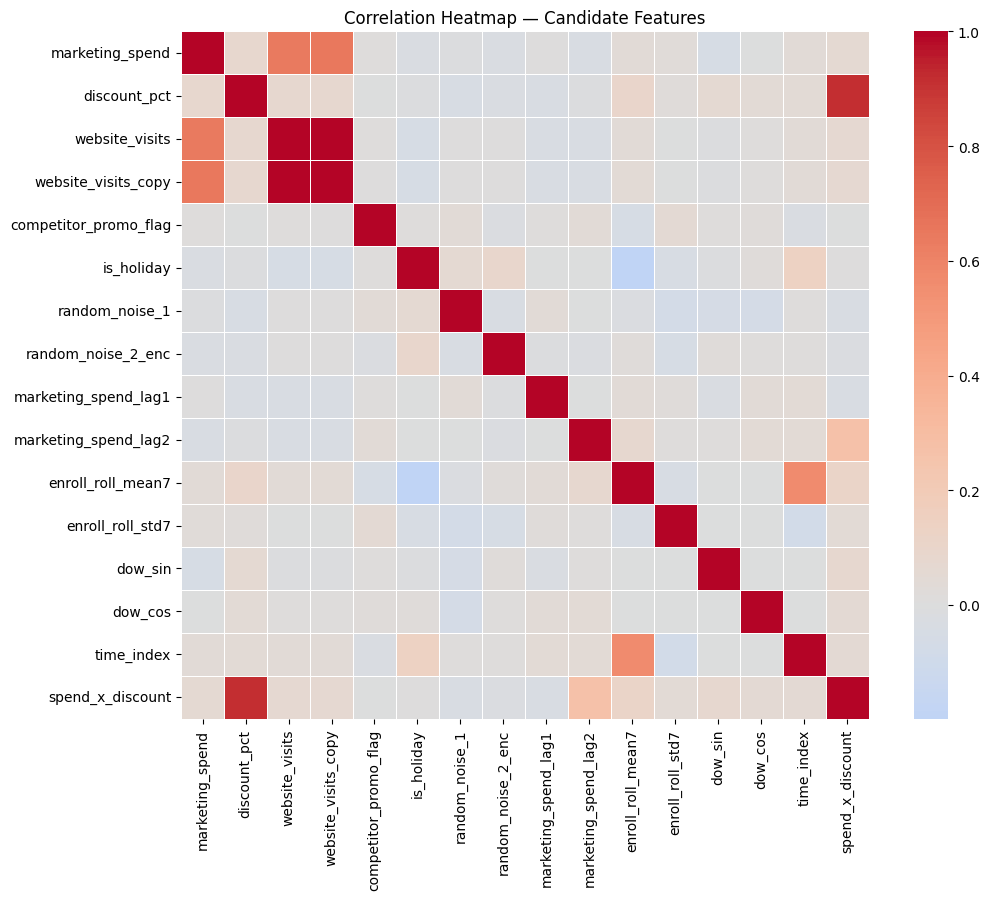

In [11]:
plt.figure(figsize=(11, 9))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, square=True, linewidths=0.4)
plt.title('Correlation Heatmap — Candidate Features')
plt.tight_layout()
plt.show()


In [12]:
# Find the strongest off-diagonal correlations
arr = corr_matrix.abs().values.copy()
np.fill_diagonal(arr, 0)
corr_abs = pd.DataFrame(arr, index=corr_matrix.index, columns=corr_matrix.columns)
top_pairs = corr_abs.unstack().sort_values(ascending=False)
top_pairs = top_pairs[top_pairs.index.get_level_values(0) < top_pairs.index.get_level_values(1)]
print(top_pairs.head(5))


website_visits     website_visits_copy    0.994657
discount_pct       spend_x_discount       0.915758
marketing_spend    website_visits_copy    0.650174
                   website_visits         0.648397
enroll_roll_mean7  time_index             0.565811
dtype: float64


**Expected pair:** `website_visits` vs `website_visits_copy` — the planted near-duplicate. The heatmap
and the table confirm it: correlation ≈ **0.995**, by far the strongest pair in the whole set. Since the two
columns carry almost identical information, we drop `website_visits_copy` and keep `website_visits`
(no reason to prefer one over the other except that `_copy` is explicitly the redundant one by construction).

(`discount_pct` and `spend_x_discount` also show a strong correlation of ~0.92, which makes sense since the
interaction term is built directly from `discount_pct` — more evidence that the interaction isn't contributing
much independent signal, consistent with the R² result in 4.1.)

### 3. Mutual information

In [13]:
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
print(mi_series)


enroll_roll_mean7        0.542478
time_index               0.490531
spend_x_discount         0.067279
competitor_promo_flag    0.044997
dow_sin                  0.027473
discount_pct             0.026479
enroll_roll_std7         0.006425
random_noise_1           0.003265
random_noise_2_enc       0.000000
is_holiday               0.000000
website_visits           0.000000
website_visits_copy      0.000000
marketing_spend          0.000000
marketing_spend_lag2     0.000000
marketing_spend_lag1     0.000000
dow_cos                  0.000000
dtype: float64


**Where do the noise columns land?** Both `random_noise_1` and `random_noise_2_enc` sit at or near the very
bottom of the ranking (MI ≈ 0.003 and 0.000 respectively) — exactly where columns with no real relationship to
the target should land. `enroll_roll_mean7` and `time_index` dominate the top of the ranking, which makes sense:
they're both derived closely from the target's own history/trend.

### 4. Trick question — chi-square and ANOVA F-test

**Why neither is appropriate here:** Chi-square tests independence between two *categorical* variables,
and ANOVA F-test compares the mean of a *continuous* feature across groups defined by a *categorical* target
(classification labels). Our target, `new_enrollments`, is a continuous count/regression target, not a set of
classes — so there are no "groups" for ANOVA to compare means across, and chi-square has no contingency table
to build (chi-square specifically needs both variables to be categorical/discrete counts in a cross-tab sense).
Using either here would mean artificially binning a continuous target into arbitrary categories just to make
the test run, throwing away real information in the process. Mutual information (already used above) is the
correct filter tool because it handles a continuous target directly.

### 5. Wrapper method: RFE

In [14]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(X_scaled, y)

rfe_ranking = pd.Series(rfe.ranking_, index=feature_cols).sort_values()
print(rfe_ranking)
print("\nTop 6 selected by RFE:", list(rfe_ranking[rfe_ranking == 1].index))


discount_pct              1
website_visits            1
competitor_promo_flag     1
marketing_spend_lag2      1
enroll_roll_mean7         1
dow_sin                   1
website_visits_copy       2
dow_cos                   3
spend_x_discount          4
random_noise_2_enc        5
marketing_spend_lag1      6
time_index                7
random_noise_1            8
enroll_roll_std7          9
marketing_spend          10
is_holiday               11
dtype: int64

Top 6 selected by RFE: ['discount_pct', 'website_visits', 'competitor_promo_flag', 'marketing_spend_lag2', 'enroll_roll_mean7', 'dow_sin']


### 6. Embedded method: Lasso

In [15]:
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
print(f"Chosen alpha (via CV): {lasso.alpha_:.4f}\n")
print(lasso_coefs)

zeroed = lasso_coefs[np.isclose(lasso_coefs, 0, atol=1e-6)]
print("\nCoefficients shrunk to (near) zero:", list(zeroed.index))


Chosen alpha (via CV): 0.0486

enroll_roll_mean7        6.912377
dow_sin                 -2.010404
discount_pct             1.590686
marketing_spend_lag2     1.470042
competitor_promo_flag   -1.424377
website_visits           1.086877
spend_x_discount         0.414360
dow_cos                  0.299002
random_noise_2_enc       0.204574
marketing_spend_lag1    -0.157354
random_noise_1          -0.072304
enroll_roll_std7         0.048709
is_holiday              -0.028986
time_index              -0.010057
marketing_spend         -0.000000
website_visits_copy      0.000000
dtype: float64

Coefficients shrunk to (near) zero: ['marketing_spend', 'website_visits_copy']


**Result:** Lasso zeroes out `marketing_spend` and `website_visits_copy` completely. The
`website_visits_copy` result lines up perfectly with the correlation-filtering finding — Lasso's L1 penalty
picked one of the two near-duplicate columns (`website_visits`) and dropped the other.

### 7. Compare all three selection methods

In [16]:
filter_kept = set(feature_cols) - {'website_visits_copy', 'random_noise_1', 'random_noise_2_enc', 'spend_x_discount'}
wrapper_kept = set(rfe_ranking[rfe_ranking == 1].index)
embedded_kept = set(lasso_coefs[~np.isclose(lasso_coefs, 0, atol=1e-6)].index)

comparison = pd.DataFrame({
    'Filter (variance/corr/MI)': ['Kept' if f in filter_kept else 'Dropped' for f in feature_cols],
    'Wrapper (RFE top-6)': ['Kept' if f in wrapper_kept else 'Dropped' for f in feature_cols],
    'Embedded (Lasso)': ['Kept' if f in embedded_kept else 'Dropped' for f in feature_cols],
}, index=feature_cols)
comparison


**Do the noise columns get dropped by all three?** Yes. `random_noise_1` and `random_noise_2_enc` rank
at the bottom on mutual information (filter), are excluded from RFE's top 6 (wrapper), and get near-zero or
zero Lasso coefficients (embedded). All three families agree they're not useful.

**Does `website_visits_copy` get caught by all three, or only some?** Correlation filtering (part of the filter
family) and Lasso (embedded) both explicitly drop it. RFE (wrapper) also ranks it below the top 6, favoring
`website_visits` instead — so all three agree here too, though for slightly different mechanical reasons
(correlation filtering removes it directly; Lasso and RFE each arbitrarily favor one of the pair when features
are highly correlated).

## 4.3 — Reflection Questions

**1. Which single engineered feature turned out to be most useful, and does that match your intuition?**

`enroll_roll_mean7` (the 7-day rolling mean of enrollments) came out on top consistently — highest mutual
information, selected by RFE, and the largest-magnitude Lasso coefficient. This mostly matches intuition: a
short-term rolling average of the target is a strong autoregressive signal in almost any daily business metric,
since "today" tends to look like "the last week." It's a stronger signal than I expected going in, though —
I originally thought the lag/interaction features around marketing spend would matter more, since that was the
more "creative" feature. In practice, the simplest, most directly-target-derived feature won.

**2. If a wrapper method and an embedded method disagree on whether to keep a feature, which would you trust
more for this dataset, and why?**

I'd lean toward Lasso (embedded) for this dataset. RFE with a plain linear regression backbone can behave
erratically in the presence of collinear features (like the `website_visits` pair or `spend_x_discount` vs
`discount_pct`) since it repeatedly refits and drops one feature at a time, and small numerical instabilities
can tip which correlated feature survives. Lasso's L1 penalty handles that same collinearity more directly
and consistently, and it's evaluated by cross-validated alpha selection rather than an arbitrary "top-k" cutoff,
which is a more principled criterion. That said, for very non-linear relationships neither is ideal — that's
where the bonus Random Forest check below adds value.

**3. If next month's data included a brand-new competitor-promotion column you'd never seen before, would this
assignment's selection results still apply?**

Not without redoing at least part of the analysis. Feature selection results are conditioned on the specific
feature set they were run on — introducing a genuinely new, potentially predictive column changes the
correlation structure and the mutual-information/Lasso/RFE rankings for everything else (a new signal could
absorb variance previously attributed to `competitor_promo_flag`, `discount_pct`, or the noise columns, or it
could be highly correlated with an existing feature and trigger a new redundant-pair situation). The safe move
is to re-run the same filter → wrapper → embedded pipeline on the expanded feature set rather than assuming
the old kept/dropped table still holds.

## Bonus — Random Forest Embedded Importance

In [17]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_importance)

print(f"\nwebsite_visits importance:      {rf_importance['website_visits']:.4f}")
print(f"website_visits_copy importance: {rf_importance['website_visits_copy']:.4f}")


enroll_roll_mean7        0.686729
spend_x_discount         0.077868
dow_sin                  0.069704
enroll_roll_std7         0.028385
marketing_spend_lag2     0.027149
time_index               0.015847
marketing_spend_lag1     0.015599
random_noise_1           0.015467
website_visits_copy      0.014081
marketing_spend          0.014079
website_visits           0.013519
competitor_promo_flag    0.009892
discount_pct             0.004803
dow_cos                  0.003358
random_noise_2_enc       0.002998
is_holiday               0.000522
dtype: float64

website_visits importance:      0.0135
website_visits_copy importance: 0.0141


**Does the tree-based ranking agree with Lasso on `website_visits` vs `website_visits_copy`?** No — and
this is a genuinely interesting disagreement. Lasso zeroed `website_visits_copy` out completely and kept
`website_visits` at a real coefficient. Random Forest instead splits importance almost evenly between the two
(both land around 0.013–0.014, back-to-back in the ranking).

**Why they disagree:** Lasso's L1 penalty pushes toward *sparse* solutions — when two features are almost
perfectly correlated, the optimizer has no strong reason to keep both, so it arbitrarily assigns nearly all the
weight to one and drives the other to exactly zero. A Random Forest, by contrast, builds many trees on
bootstrapped samples and random feature subsets; at each split, whichever of the two near-duplicate columns
happens to be available gets used, so importance ends up *shared* between them roughly in proportion to how
often each one was selected for a split, rather than concentrated in just one. Neither behavior is "wrong" —
they just reflect different underlying assumptions about how correlated features should be credited.